#Trabajo Final_Herramientas Básicas para el Análisis de Datos

##Proyecto Mecanismo de Integración - Devolución Superintendencia de Servicios de Salud

###**Contexto del Trabajo**

Este proyecto analiza las devoluciones realizadas por la Superintendencia de Servicios de Salud (SSS) en relación a la presentación de prestaciones de discapacidad.

####*Objetivo*
El objetivo del presente proyecto es identificar patrones en las devoluciones de prestaciones de discapacidad, analizando las causas más frecuentes y su comportamiento en el tiempo, con el fin de mejorar la gestión y reducir errores en futuras presentaciones.
Asimismo, el análisis se centrará específicamente en las devoluciones correspondientes a los meses de enero y febrero del año 2026, con el propósito de realizar un estudio acotado y detallado de dicho período.
Adicionalmente, se evaluará el impacto económico de dichas devoluciones, mediante la comparación entre los montos presentados y los efectivamente subsidiados por la Superintendencia de Servicios de Salud.

####*Preguntas de análisis:*
⏩**Pregunta principal:**
¿Cuáles son los principales motivos de devolución de prestaciones de discapacidad por parte de la SSS durante enero y febrero de 2026, y cuál es su impacto en los montos efectivamente subsidiados?

⏩**Subpreguntas de análisis**
* ¿Qué proporción de prestaciones son devueltas?
* ¿Cuáles son los motivos de devolución más frecuentes?
* ¿Cómo varían las devoluciones entre enero y febrero?
* ¿Qué tipo de prestación presenta más errores?
* ¿Qué porcentaje del monto presentado es finalmente subsidiado?


⏩**KPIs (Indicadores Clave)**


*   Total de prestaciones
*   Total de devoluciones
*   % devoluciones
*   Motivo más frecuente
*  % monto subsidiado vs solicitado 💰
*  Tipo de prestación con más devoluciones

###**1. Búsqueda y selección del dataset**


Para el desarrollo del presente proyecto se utilizará un dataset de elaboración propia, basado en información real correspondiente a la presentación de prestaciones de discapacidad ante la Superintendencia de Servicios de Salud (SSS).

El dataset integra información de los lotes 12 y 13, correspondientes a los meses de enero y febrero del año 2026, respectivamente.
La elección de este conjunto de datos resulta pertinente, ya que permite analizar tanto la cantidad de devoluciones como su impacto económico, a partir de los montos solicitados y los efectivamente subsidiados.

Asimismo, el dataset cuenta con un volumen adecuado de registros y variables relevantes para llevar a cabo un análisis exploratorio completo.

###**2. Ingesta y limpieza (Python)**

En esta etapa se realiza la carga del dataset desde un archivo Excel almacenado en Google Drive. Posteriormente, se lleva a cabo una revisión inicial de la estructura de los datos, tipos de variables y posibles inconsistencias, con el objetivo de preparar la información para su análisis.

####*Carga*

In [3]:
  #Importación de librerias necesarias para la carga
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

  # Importación de data set en una variable llamada "df"
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/Capacitaciones/Colab Notebooks/Lote_presentación_enero_febrero2026.xls'

df = pd.read_excel(ruta)

df.head()
df.info()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   lote                   16383 non-null  int64         
 1   referencia             16383 non-null  object        
 2   tipo_registro          16383 non-null  object        
 3   ofi_expe               16383 non-null  int64         
 4   expe                   16383 non-null  int64         
 5   estado_expe            16383 non-null  object        
 6   cuit                   16383 non-null  object        
 7   prestador              16383 non-null  object        
 8   periodo_presen         16383 non-null  datetime64[ns]
 9   tipo_compro            16383 non-null  object        
 10  nro_comprob            16383 non-null  object    

####*Diccionario del Data Fame (df)*
| Columna               | Tipo de dato | Descripción                                                      |
| --------------------- | ------------ | ---------------------------------------------------------------- |
| lote                  | entero       | Número de lote de presentación (ej: 12 corresponde a enero 2026) |
| referencia            | texto        | Tipo o referencia del proceso de presentación                    |
| tipo_registro         | entero       | Código que identifica el tipo de registro dentro del archivo     |
| ofi_expe              | entero       | Código de oficina o expediente asociado                          |
| expe                  | entero       | Número de expediente                                             |
| estado_expe           | texto        | Estado del expediente (ej: liquidado, observado, etc.)           |
| cuit                  | texto        | CUIT del prestador                                               |
| prestador             | texto        | Identificación del prestador                                     |
| periodo_presen        | texto/fecha  | Fecha o período en que se realizó la presentación                |
| tipo_compro           | texto        | Tipo de comprobante                                              |
| nro_comprob           | texto        | Número de comprobante                                            |
| cae_cai               | texto        | Código de autorización electrónica o fiscal                      |
| impor_comprob         | numérico     | Importe total del comprobante                                    |
| periodo_presta        | texto        | Período al que corresponde la prestación                         |
| ape_y_nom             | texto        | Apellido y nombre del beneficiario                               |
| prestac               | texto        | Código de la prestación                                          |
| exten_deno            | texto        | Descripción de la prestación                                     |
| canti                 | entero       | Cantidad de prestaciones                                         |
| impor_soli            | numérico     | Importe solicitado                                               |
| dependencia           | texto        | Dependencia administrativa                                       |
| zona_desfavorable     | texto        | Indica si corresponde zona desfavorable                          |
| respuesta             | texto        | Resultado de la auditoría (Ok / Error)                           |
| error                 | texto        | Descripción del error en caso de devolución                      |
| nro_liq               | entero       | Número de liquidación                                            |
| periodo_pres          | texto        | Período de presentación                                          |
| importe_subsidiado    | numérico     | Importe subsidiado                                               |
| clave_rendicion       | texto        | Identificador de rendición                                       |
| impor_liqui_rendicion | numérico     | Importe liquidado en la rendición                                |
| nro_envio_afip        | texto        | Número de envío a AFIP                                           |
| fecha_proceso         | fecha        | Fecha en que se procesó el registro                              |
| nombre_archivo        | texto        | Nombre del archivo de origen                                     |
| id_reg                | entero       | Identificador único del registro                                 |
| reproceso             | texto        | Indica si el registro fue reprocesado                            |
| tipo_compro_sss       | texto        | Tipo de comprobante según SSS                                    |
| fecha_emision         | fecha        | Fecha de emisión del comprobante                                 |
| prestac_sss           | texto        | Código de prestación según SSS                                   |
| es_presentable        | texto        | Indica si la prestación es válida para presentación              |


####*Limpieza*

In [4]:
# eliminar duplicados
df = df.drop_duplicates()

# crear variable periodo
df['periodo'] = df['lote'].apply(lambda x: 'Enero 2026' if x == 12 else 'Febrero 2026')

# variable devolucion
df['devolucion'] = df['respuesta'].apply(lambda x: 1 if x == 'Error' else 0)

# limpiar errores
df['error'] = df['error'].fillna('Sin error')

# eliminar columnas
columns_to_drop = ['nombre_archivo', 'id_reg', 'tipo_compro_sss']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# VERIFICACIÓN
print("Primeras 5 filas de 'lote' y 'periodo':")
display(df[['lote','periodo']].head())

print("\nÚltimas 5 filas de 'lote' y 'periodo':")
display(df[['lote','periodo']].tail())

Primeras 5 filas de 'lote' y 'periodo':


,lote,periodo
0,12,Enero 2026
1,12,Enero 2026
2,12,Enero 2026
3,12,Enero 2026
4,12,Enero 2026



Últimas 5 filas de 'lote' y 'periodo':


,lote,periodo
16378,13,Febrero 2026
16379,13,Febrero 2026
16380,13,Febrero 2026
16381,13,Febrero 2026
16382,13,Febrero 2026


El dataset presenta una estructura consistente, sin valores nulos relevantes en las variables principales, lo que permite avanzar con el análisis sin necesidad de imputaciones complejas.
Se realizó un proceso de limpieza que incluyó la eliminación de registros duplicados y la depuración de valores faltantes en la variable de errores.

Asimismo, se eliminaron las columnas nombre_archivo, id_reg y tipo_compro_sss, debido a que no aportan información relevante para responder las preguntas del análisis, ya que corresponden a identificadores técnicos o administrativos.

Por otro lado, se crearon nuevas variables para optimizar el análisis, como la variable periodo, que permite distinguir entre los meses analizados, y una variable binaria de devoluciones, que facilita la identificación de registros con error.
Estas transformaciones contribuyen a mejorar la calidad del dataset y a preparar la información para un análisis más eficiente y enfocado en los objetivos del proyecto.

###**3. Exploración y visualización**


En esta etapa se realiza un análisis exploratorio de los datos con el objetivo de identificar patrones, tendencias y relaciones entre variables, utilizando visualizaciones claras que permitan interpretar los resultados.

In [5]:
#3.1 Exploración inicial
print("Valores nulos:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

Valores nulos:
lote                        0
referencia                  0
tipo_registro               0
ofi_expe                    0
expe                        0
estado_expe                 0
cuit                        0
prestador                   0
periodo_presen              0
tipo_compro                 0
nro_comprob                 0
cae_cai                     0
impor_comprob               0
periodo_presta              0
ape_y_nom                   0
prestac                     0
exten_deno                  0
canti                       0
impor_soli                  0
dependencia                 0
zona_desfavorable           0
respuesta                   0
error                       0
nro_liq                  3271
periodo_pres             3271
importe_subsidiado       3413
clave_rendicion          3165
impor_liqui_rendicion    3165
nro_envio_afip           3165
fecha_proceso            3165
reproceso                   0
fecha_emision               0
prestac_sss              

In [6]:
# 1. Crear variable devolucion
df['devolucion'] = df['respuesta'].str.strip().str.upper().str.contains('ERROR').astype(int)

# 2. Limpiar columna reproceso
df['reproceso'] = df['reproceso'].astype(str).str.strip().str.upper()

# 3. Filtrar SOLO registros sin reproceso
df_sin_reproceso = df[df['reproceso'].str.contains('N', na=False)]

# 4. Verificar montos
print("Solicitado:", df_sin_reproceso['impor_soli'].sum())
print("Subsidiado:", df_sin_reproceso['importe_subsidiado'].sum())

# 5. Calcular porcentaje (ESTE ES EL KPI)
porcentaje = (
    df_sin_reproceso['importe_subsidiado'].sum() /
    df_sin_reproceso['impor_soli'].sum()
) * 100

# 6. Resultado final
print("% subsidiado:", round(porcentaje, 2))


Solicitado: 4013227486.2200003
Subsidiado: 5525600755.289999
% subsidiado: 137.68


In [7]:
df['reproceso'].value_counts()

,count
reproceso,
N ,14445
S ,1938


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 0 ( ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


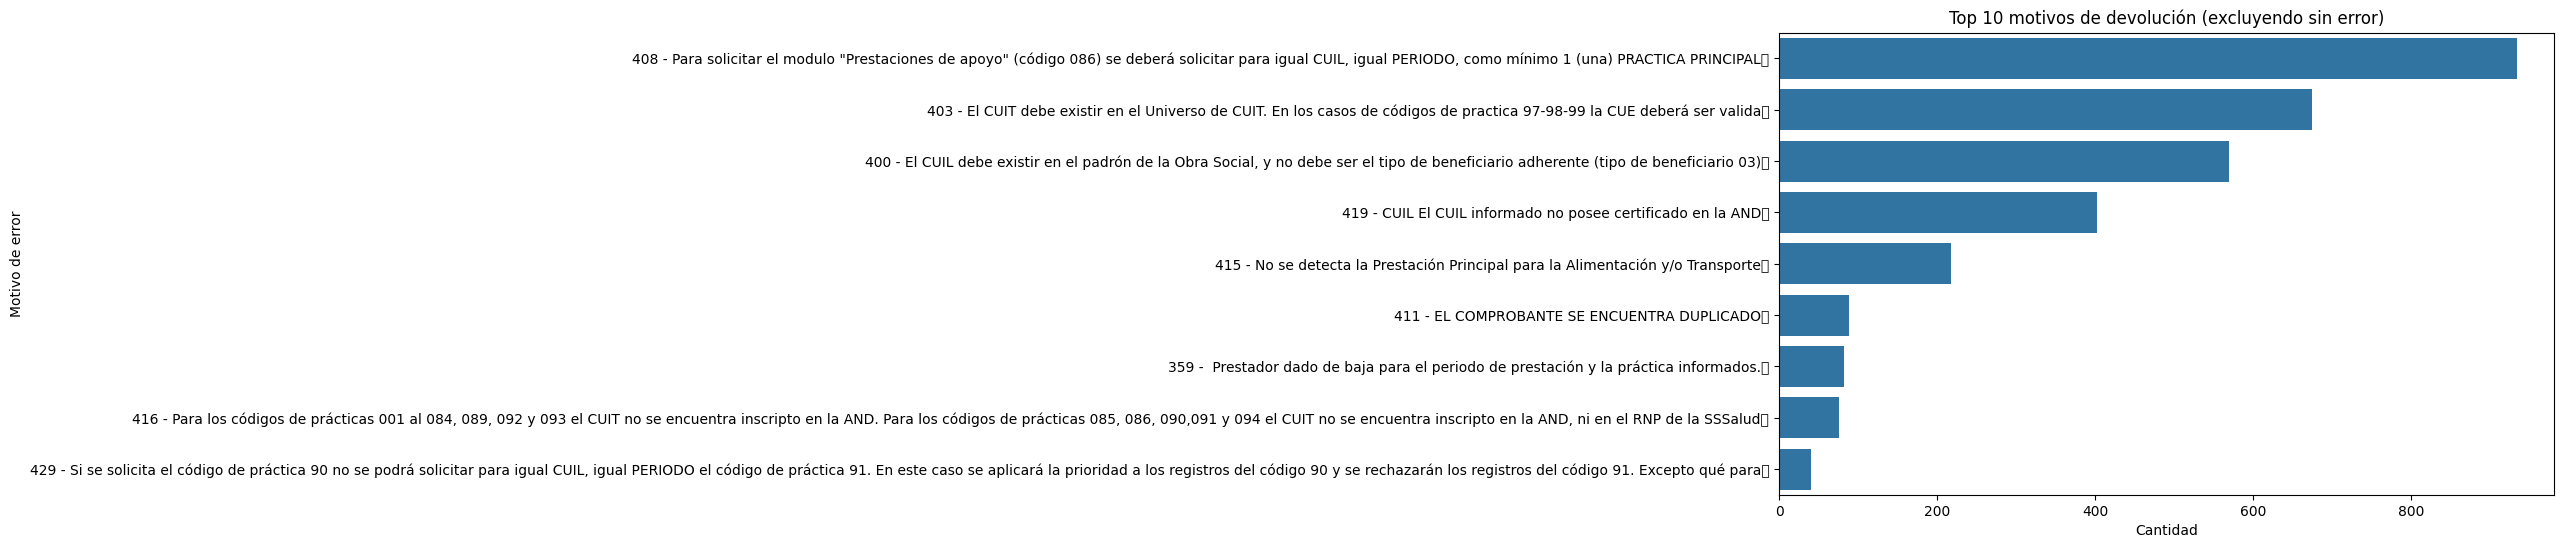

In [9]:
#3.3 Visualizaciones
#📊 Motivos de devolución
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='error',
    order=df['error'].value_counts().index[1:10]  # excluye "Sin error"
)

plt.title('Top 10 motivos de devolución (excluyendo sin error)')
plt.xlabel('Cantidad')
plt.ylabel('Motivo de error')

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 0 ( ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


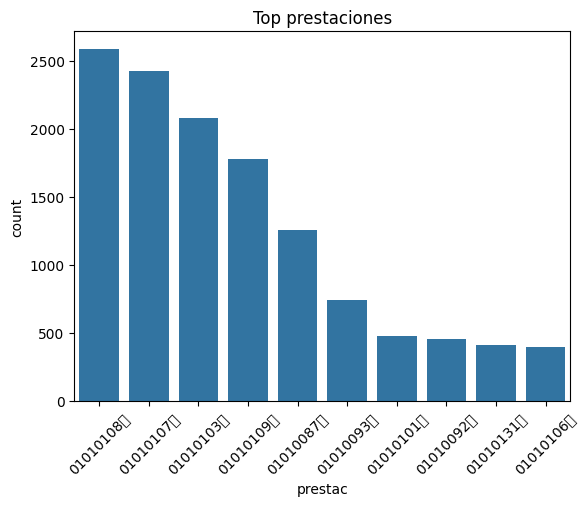

In [10]:
#📊 Devoluciones por tipo de prestación
sns.countplot(data=df, x='prestac', order=df['prestac'].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title('Top prestaciones')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 0 ( ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


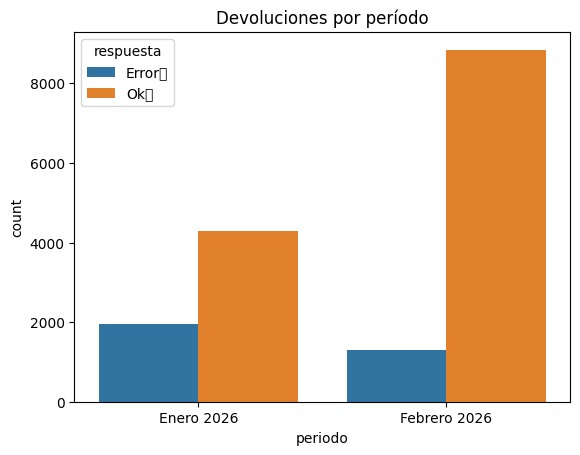

In [11]:
#📊 Evolución por periodo
sns.countplot(data=df, x='periodo', hue='respuesta')
plt.title('Devoluciones por período')
plt.show()

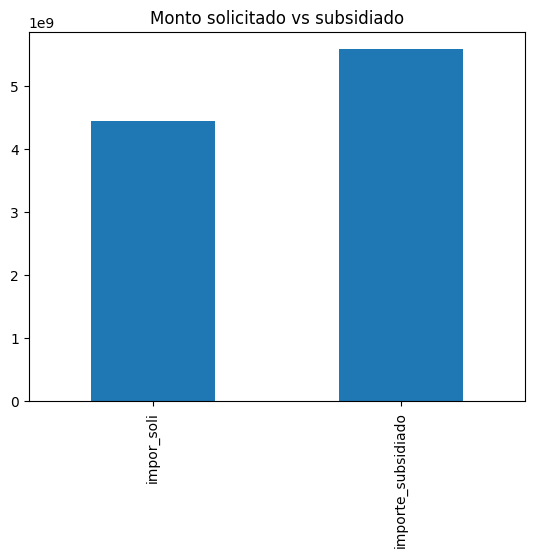

In [12]:
#📊 Impacto económico
df[['impor_soli','importe_subsidiado']].sum().plot(kind='bar')
plt.title('Monto solicitado vs subsidiado')
plt.show()

####*Interpretación*

Del total de prestaciones analizadas, se observa que el 19,82% presentan devoluciones por parte de la Superintendencia de Servicios de Salud, lo que indica que aproximadamente una de cada cinco prestaciones contiene errores en su presentación.

En cuanto a los motivos de devolución, se identifica una fuerte concentración en un conjunto reducido de errores. El más frecuente corresponde al código 408, vinculado a la ausencia de una práctica principal obligatoria, seguido por errores relacionados con validaciones de CUIT (código 403) y CUIL (código 400). Esto evidencia que gran parte de las devoluciones se originan en inconsistencias administrativas y de carga de datos.

Al analizar la distribución de devoluciones por período, no se observan diferencias significativas entre enero y febrero, manteniéndose un comportamiento similar en ambos meses.

Desde el punto de vista económico, se observa que el porcentaje de subsidio supera el 100%, indicando que el monto subsidiado excede al solicitado, lo cual puede estar asociado a procesos de reliquidación. Al analizar únicamente los registros sin reprocesos, este comportamiento se mantiene, lo que indica que la variable de importe subsidiado no guarda una relación directa con el monto presentado en cada registro.

Esto sugiere la existencia de ajustes, reliquidaciones o pagos correspondientes a otros períodos, lo cual refleja la complejidad del proceso de liquidación. En consecuencia, el análisis económico debe interpretarse considerando que los montos subsidiados pueden incluir componentes adicionales más allá de la presentación original.

###**4. Construcción de Dashboard (Power BI)**

Se desarrolló un dashboard en Power BI que permite visualizar de manera dinámica los principales indicadores del análisis, incluyendo la cantidad de devoluciones, los motivos más frecuentes, la distribución por tipo de prestación y el impacto económico. Esta herramienta facilita la toma de decisiones y la identificación de oportunidades de mejora en el proceso de presentación.

###**5. Crear publicación en GitHub**


El proyecto fue publicado en GitHub incluyendo el dataset utilizado, el notebook de análisis en Python y la documentación correspondiente. Esto permite la reproducibilidad del análisis y su futura actualización.

###**6. Conclusión**

El análisis realizado permitió identificar que las devoluciones de prestaciones de discapacidad presentan patrones claros y repetitivos, principalmente asociados a errores administrativos y de validación de datos. La alta concentración de errores en pocos códigos sugiere que es posible reducir significativamente las devoluciones mediante mejoras en los procesos de carga y control previo.

Asimismo, el análisis económico evidenció que los montos subsidiados no guardan una relación directa con los importes presentados en el período, lo que refleja la complejidad del sistema de liquidación y la existencia de ajustes posteriores.

En este sentido, el trabajo aporta información relevante para optimizar la gestión de prestaciones, reducir errores y mejorar la eficiencia en la presentación ante la Superintendencia de Servicios de Salud.

In [15]:
#Exportar dataset limpio desde Colab
import re

def limpiar_texto(x):
    if isinstance(x, str):
        return re.sub(r'[\x00-\x1F\x7F-\x9F]', '', x)
    return x

df = df.applymap(limpiar_texto)


df.to_excel('dataset_limpio.xlsx', index=False)

/tmp/ipykernel_1166/3722404242.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(limpiar_texto)
